# Giai đoạn 10 — Giải thích mô hình bằng SHAP (XAI)

Chín giai đoạn trước trả lời *"mô hình đoán ngành nào"*. Notebook này trả lời
*"**vì sao** nó đoán như vậy"*.

## Dùng gì

| Thứ | Vai trò |
|---|---|
| **XAI** | lĩnh vực — mục tiêu làm cho quyết định của mô hình hiểu được |
| **SHAP** | phương pháp trong XAI, dựa trên giá trị Shapley (lý thuyết trò chơi) |
| **TreeSHAP** | thuật toán hiện thực SHAP cho mô hình cây — chính xác, không lấy mẫu |
| `pred_contribs=True` | TreeSHAP **có sẵn trong `xgboost`**, không cần thư viện ngoài |

Không huấn luyện thêm mô hình nào. TreeSHAP đọc thẳng cấu trúc cây của hai mô hình
đã có từ Giai đoạn 8 (476 cây ở tầng 1, 6.786 cây ở tầng 2).

> **Vì sao không dùng thư viện `shap` để tính?** `shap` 0.49 đọc `base_score` của mô
> hình đa lớp XGBoost 3.2 sai kiểu — nó mong một số vô hướng trong khi XGBoost lưu
> một vector mỗi lớp một phần tử, nên vỡ ở cả bốn cách gọi. `pred_contribs` chạy
> đúng **cùng thuật toán TreeSHAP** ngay trong XGBoost. Thư viện `shap` ở đây chỉ
> dùng để **vẽ**.

## Bài toán riêng của kiến trúc hai tầng

Điểm xếp hạng cuối là tích hai xác suất: `P(ngành) ∝ P₂(ngành) × P₁(khối)^β`.
Nhân trong không gian xác suất chính là **cộng trong không gian log**, nên với một
học sinh cố định:

```
s(ngành) = margin₂(ngành) + β·margin₁(khối) + C
         = [base] + Σᵢ [ φ₂ᵢ(ngành) + β·φ₁ᵢ(khối) ]
```

`C` là hằng số chuẩn hoá softmax — **giống nhau cho cả 39 ngành** của học sinh đó nên
không đổi thứ hạng. Vậy đóng góp hợp nhất của đặc trưng `i` là **chính xác**
`φ₂ᵢ + β·φ₁ᵢ`, không phải xấp xỉ.

Nhờ vậy ta đưa ra **một** biểu đồ giải thích thẳng con số cuối cùng, thay vì hai biểu
đồ rời cho hai tầng rồi để người đọc tự ghép. Bước 10.2 kiểm chứng khẳng định này.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from pathlib import Path
from xgboost import XGBClassifier, DMatrix

# ── Thiết lập kiểu biểu đồ dùng chung cho toàn bộ báo cáo ────────────────────
plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 220, "savefig.bbox": "tight",
    "font.family": "DejaVu Sans", "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlepad": 14,
    "axes.labelsize": 11, "axes.labelpad": 8,
    "axes.grid": True, "grid.alpha": 0.18, "grid.linestyle": "-", "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.spines.left": False, "axes.edgecolor": "#B0B7BF",
    "figure.facecolor": "white", "axes.facecolor": "white",
    "legend.frameon": False, "legend.fontsize": 10,
    "xtick.labelsize": 10, "ytick.labelsize": 10,
    "xtick.color": "#4A5560", "ytick.color": "#4A5560",
    "axes.labelcolor": "#2C3E50", "text.color": "#2C3E50",
})

C_THAT  = "#D64550"
C_GA    = "#2BA84A"
C_XANH  = "#3B7DD8"
C_CAM   = "#E8873A"
C_TIM   = "#8E5FBF"
C_XAM   = "#AEB6BF"
C_DAM   = "#2C3E50"
C_KHOI  = ["#3B7DD8", "#E8873A", "#8E5FBF", "#19A2A2", "#D64550", "#C9A227", "#5D6D7E"]


def chu_thich(fig, text, y=None):
    # Dòng chú giải nằm dưới hình — nêu kết luận rút ra từ biểu đồ.
    # Chú giải (legend) đặt ngoài trục bằng bbox_to_anchor y âm có thể thò xuống
    # dưới đáy hình; khi đó phải hạ dòng chú thích xuống dưới nó, nếu không hai
    # bên đè lên nhau (bbox_inches="tight" nới khung chứ không dời chữ ra).
    if y is None:
        y = -0.02
        fig.canvas.draw()
        r = fig.canvas.get_renderer()
        hop_ds = [lg.get_window_extent(r) for lg in fig.legends]
        hop_ds += [ax.get_legend().get_window_extent(r)
                   for ax in fig.axes if ax.get_legend() is not None]
        for hop in hop_ds:
            day = hop.transformed(fig.transFigure.inverted()).y0
            if day < y:
                y = day - 0.035
    fig.text(0.5, y, text, ha="center", va="top", fontsize=10.5,
             color="#5A6672", style="italic", wrap=True)


def luu(fig, thu_muc, ten, chu=None):
    if chu:
        chu_thich(fig, chu)
    fig.savefig(thu_muc / ten, dpi=220, bbox_inches="tight", facecolor="white")
    print(f"   💾 Đã lưu hình: {ten}")


PROC       = Path("../data/processed")
MODEL_DIR  = PROC / "08_model"
READY_DIR  = PROC / "07_model_ready"
OUTPUT_DIR = PROC / "10_xai"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
BETA = 0.6          # hệ số kết hợp hai tầng, chốt ở Giai đoạn 8
np.random.seed(SEED)

X_test = pd.read_csv(READY_DIR / "X_test.csv")
y_nganh = pd.read_csv(READY_DIR / "y_test_nganh.csv").iloc[:, 0].values
y_khoi  = pd.read_csv(READY_DIR / "y_test_khoi.csv").iloc[:, 0].values
M       = np.load(READY_DIR / "M_nganh_khoi.npy")      # 39 x 7, one-hot ngành -> khối
COT     = list(X_test.columns)

lab        = json.loads((READY_DIR / "label_encoder_mapping.json").read_text())
TEN_NGANH  = {int(k): v for k, v in lab["idx_to_name"].items()}
KHOI_CUA_NGANH = M.argmax(1)

m1 = XGBClassifier(); m1.load_model(MODEL_DIR / "model_stage1_khoinganh.json")
m2 = XGBClassifier(); m2.load_model(MODEL_DIR / "model_stage2_nganh.json")
B1, B2 = m1.get_booster(), m2.get_booster()

TEN_KHOI = json.loads((MODEL_DIR / "metrics_summary.json").read_text())["auc_roc"]["tang1_tung_khoi"]
TEN_KHOI = list(TEN_KHOI.keys())

print(f"Tập kiểm tra   : {X_test.shape[0]} học sinh × {X_test.shape[1]} đặc trưng")
print(f"Nhãn           : {len(set(y_nganh))} ngành · {len(set(y_khoi))} khối")
print(f"Số cây         : tầng 1 = {len(B1.get_dump()):,}   tầng 2 = {len(B2.get_dump()):,}")
print(f"β              : {BETA}")

Tập kiểm tra   : 102 học sinh × 43 đặc trưng
Nhãn           : 39 ngành · 7 khối
Số cây         : tầng 1 = 476   tầng 2 = 6,786
β              : 0.6


## Bước 10.1 — Tính giá trị SHAP và kiểm chứng tính cộng tính

`pred_contribs=True` trả về mảng `(n_mẫu, n_lớp, n_đặc_trưng + 1)`. Cột cuối là
**base value** — giá trị kỳ vọng của mô hình khi chưa biết gì về học sinh.

Tính chất nền tảng của SHAP: **tổng mọi đóng góp cộng base phải bằng đúng đầu ra thô
(margin) của mô hình**. Nếu đẳng thức này sai thì mọi biểu đồ phía sau đều vô nghĩa,
nên kiểm ngay bằng `assert`.

In [2]:
d_test = DMatrix(X_test, feature_names=COT)

shap1 = B1.predict(d_test, pred_contribs=True)   # (102, 7, 44)
shap2 = B2.predict(d_test, pred_contribs=True)   # (102, 39, 44)
print(f"SHAP tầng 1 : {shap1.shape}")
print(f"SHAP tầng 2 : {shap2.shape}   ← cột cuối là base value")

# ── Kiểm chứng cộng tính: Σφ + base == margin ────────────────────────────────
margin1 = B1.predict(d_test, output_margin=True)
margin2 = B2.predict(d_test, output_margin=True)
sai1 = np.abs(shap1.sum(-1) - margin1).max()
sai2 = np.abs(shap2.sum(-1) - margin2).max()

print(f"\nSai lệch |Σφ + base − margin|")
print(f"   tầng 1 : {sai1:.3e}")
print(f"   tầng 2 : {sai2:.3e}")

assert sai1 < 1e-4, f"Tầng 1 vi phạm tính cộng tính: {sai1}"
assert sai2 < 1e-4, f"Tầng 2 vi phạm tính cộng tính: {sai2}"
print("\n✔ Cả hai tầng thoả tính cộng tính — giá trị SHAP phân rã đúng đầu ra của mô hình.")

SHAP tầng 1 : (102, 7, 44)
SHAP tầng 2 : (102, 39, 44)   ← cột cuối là base value

Sai lệch |Σφ + base − margin|
   tầng 1 : 1.192e-06
   tầng 2 : 2.146e-06

✔ Cả hai tầng thoả tính cộng tính — giá trị SHAP phân rã đúng đầu ra của mô hình.


## Bước 10.2 — Kiểm chứng công thức hợp nhất hai tầng

Đây là bước quan trọng nhất của notebook. Nếu `φ₂ + β·φ₁` **không** tái tạo được thứ
hạng mà hệ thống thật sự hiển thị thì toàn bộ thiết kế giải thích phải làm lại.

Cách kiểm: dựng lại bảng xếp hạng 39 ngành **chỉ từ giá trị SHAP**, rồi so với thứ
hạng tính theo đường thông thường (nhân xác suất). Hai bên phải trùng nhau.

In [3]:
# (A) Đường thông thường — đúng cách `major_predictor.recommend()` xếp hạng
P1 = m1.predict_proba(X_test)
P2 = m2.predict_proba(X_test)
diem_that = P2 * np.power(P1 @ M.T, BETA)

# (B) Chỉ từ SHAP — cộng trong không gian log
diem_shap = shap2.sum(-1) + BETA * shap1.sum(-1)[:, KHOI_CUA_NGANH]

trung_top1 = (diem_that.argmax(1) == diem_shap.argmax(1)).mean()
trung_bang = np.mean([
    (np.argsort(-diem_that[i]) == np.argsort(-diem_shap[i])).all()
    for i in range(len(X_test))
])

print(f"Trùng ngành Top-1            : {trung_top1:.1%}")
print(f"Trùng TOÀN BỘ thứ hạng 39    : {trung_bang:.1%}")

assert trung_top1 == 1.0, "Công thức hợp nhất không tái tạo được Top-1"
assert trung_bang == 1.0, "Công thức hợp nhất không tái tạo được toàn bộ thứ hạng"
print("\n✔ φ₂ + β·φ₁ tái tạo CHÍNH XÁC thứ hạng mà hệ thống hiển thị,")
print("  trên cả 102 học sinh và cả 39 vị trí — không chỉ Top-1.")

Trùng ngành Top-1            : 100.0%
Trùng TOÀN BỘ thứ hạng 39    : 100.0%

✔ φ₂ + β·φ₁ tái tạo CHÍNH XÁC thứ hạng mà hệ thống hiển thị,
  trên cả 102 học sinh và cả 39 vị trí — không chỉ Top-1.


## Bước 10.3 — Bảng dịch tên đặc trưng

`likert_dinh_duong` không phải thứ đưa cho học sinh đọc. Hai chỗ dễ dịch sai:

- `diem_tb_z` **không phải** "điểm trung bình" mà là **mặt bằng điểm so với chung**
  (z-score). Ghi nhầm thì học sinh thấy *"Điểm trung bình: −0,3"* sẽ hiểu sai hoàn toàn.
- Ô điểm **khuyết** vẫn có đóng góp SHAP hợp lệ, vì XGBoost học một hướng rẽ riêng cho
  nhánh khuyết — *"không thi môn này"* tự nó đã là thông tin. Nhưng hiện ra
  *"Điểm Hóa: nan"* thì vô nghĩa, phải đổi thành *"Không thi môn Hóa"*.

In [4]:
DICH = {
    "likert_nang_dong": "Năng động", "likert_huong_noi": "Hướng nội",
    "likert_sang_tao": "Sáng tạo", "likert_logic": "Tư duy logic",
    "likert_to_mo": "Tò mò", "likert_thi_nghiem": "Thích thí nghiệm",
    "likert_moi_truong": "Quan tâm môi trường", "likert_dinh_duong": "Quan tâm dinh dưỡng",
    "likert_tranh_luan": "Thích tranh luận", "likert_thiet_ke": "Thích thiết kế",
    "diem_tb_z": "Mặt bằng điểm", "diem_max_z": "Môn mạnh nhất", "diem_min_z": "Môn yếu nhất",
    "gioi_tinh_ma": "Giới tính", "muc_tieu_ma": "Mục tiêu sau tốt nghiệp",
}

def ten_dep(cot: str) -> str:
    if cot in DICH:
        return DICH[cot]
    return (cot.replace("diem_", "Điểm ")
               .replace("to_hop_", "Tổ hợp ")
               .replace("nhom_to_hop_TN", "Nhóm Tự nhiên")
               .replace("nhom_to_hop_XH", "Nhóm Xã hội")
               .replace("nhom_to_hop_HH", "Nhóm Hỗn hợp"))

def mo_ta_gia_tri(cot: str, v: float) -> str:
    """Chuỗi hiển thị cho giá trị đặc trưng — xử lý riêng ô khuyết."""
    if pd.isna(v):
        if cot.startswith("diem_"):
            return "không thi"
        return "chưa có"
    if cot.startswith("likert_"):
        return f"{v:.0f}/5"
    if cot.endswith("_z"):
        return f"{v:+.2f}"            # z-score: làm tròn, giữ dấu cho dễ đọc
    if cot.startswith(("to_hop_", "nhom_to_hop_")):
        return "có" if v else "không"
    return f"{v:.4g}"

TEN_DEP = [ten_dep(c) for c in COT]
print(f"Đã dịch {len(TEN_DEP)} tên đặc trưng. Ví dụ:")
for c in ["likert_logic", "diem_tb_z", "diem_Hoa", "to_hop_A00", "nhom_to_hop_TN"]:
    print(f"   {c:20} → {ten_dep(c)}")

Đã dịch 43 tên đặc trưng. Ví dụ:
   likert_logic         → Tư duy logic
   diem_tb_z            → Mặt bằng điểm
   diem_Hoa             → Điểm Hoa
   to_hop_A00           → Tổ hợp A00
   nhom_to_hop_TN       → nhom_Tổ hợp TN


## Bước 10.4 — Hàm giải thích cho một học sinh

Đây chính là hàm sẽ bê nguyên sang backend. Điểm cần chú ý: ở chế độ **Tư vấn**
người dùng tự chọn khối nên `P₁` bị ép bằng 1, tầng 1 **không tham gia xếp hạng** —
do đó cũng không được xuất hiện trong phần giải thích.

In [5]:
def giai_thich(i: int, mode: str = "explore", j_nganh: int | None = None, top: int = 6) -> dict:
    """Giải thích vì sao mô hình xếp `j_nganh` ở vị trí đó cho học sinh thứ `i`."""
    if j_nganh is None:
        j_nganh = int(diem_that[i].argmax())
    k_khoi = int(KHOI_CUA_NGANH[j_nganh])

    # Chế độ guided: P₁ = 1 ⇒ tầng 1 không đóng góp vào thứ hạng
    he_so_t1 = 0.0 if mode == "guided" else BETA
    phi = shap2[i, j_nganh, :-1] + he_so_t1 * shap1[i, k_khoi, :-1]

    tong_abs = np.abs(phi).sum()
    idx = np.argsort(-np.abs(phi))[:top]
    return {
        "hoc_sinh": i,
        "mode": mode,
        "nganh": TEN_NGANH[j_nganh],
        "base": float(shap2[i, j_nganh, -1] + he_so_t1 * shap1[i, k_khoi, -1]),
        "features": [
            {
                "ten": TEN_DEP[k],
                "gia_tri": mo_ta_gia_tri(COT[k], X_test.iloc[i, k]),
                "dong_gop": float(phi[k]),
                "phan_tram": float(abs(phi[k]) / tong_abs * 100),
                "tang2": float(shap2[i, j_nganh, k]),
                "tang1": float(he_so_t1 * shap1[i, k_khoi, k]),
            }
            for k in idx
        ],
    }


def in_giai_thich(r: dict, tieu_de: str = "") -> None:
    print(f"\n  {tieu_de}")
    print(f"  Ngành mô hình xếp #1: {r['nganh']}")
    print("  " + "─" * 64)
    for f in r["features"]:
        g = f["dong_gop"]
        thanh = "█" * min(int(abs(g) * 13), 15)
        ve = ("◀" + thanh).ljust(17) if g < 0 else (thanh + "▶").ljust(17)
        print("  %-22s %9s  %s %+6.2f  (%4.1f%%)"
              % (f["ten"], f["gia_tri"], ve, g, f["phan_tram"]))
    print("  " + "─" * 64)
    print("  ▶ đẩy lên   ◀ kéo xuống   độ dài = mức ảnh hưởng")


in_giai_thich(giai_thich(0), "HỌC SINH #1 — chế độ Khám phá")
in_giai_thich(giai_thich(7), "HỌC SINH #8 — chế độ Khám phá")

r_guided = giai_thich(0, mode="guided")
in_giai_thich(r_guided, "HỌC SINH #1 — chế độ Tư vấn (đã tự chọn khối)")
assert all(f["tang1"] == 0.0 for f in r_guided["features"]), "guided vẫn còn thành phần tầng 1"
print("\n  ✔ Chế độ Tư vấn: mọi tang1 = 0 — tầng 1 không tham gia, đúng thiết kế.")


  HỌC SINH #1 — chế độ Khám phá
  Ngành mô hình xếp #1: Công nghệ kỹ thuật cơ điện tử
  ────────────────────────────────────────────────────────────────
  Giới tính                      1  ██████████▶        +0.78  (19.7%)
  Tư duy logic                 5/5  ███████▶           +0.61  (15.4%)
  Thích thí nghiệm             5/5  ███████▶           +0.55  (13.8%)
  Thích tranh luận             5/5  ████▶              +0.35  ( 8.9%)
  Điểm Hoa                       9  ███▶               +0.28  ( 7.1%)
  Hướng nội                    1/5  ◀███               -0.25  ( 6.2%)
  ────────────────────────────────────────────────────────────────
  ▶ đẩy lên   ◀ kéo xuống   độ dài = mức ảnh hưởng

  HỌC SINH #8 — chế độ Khám phá
  Ngành mô hình xếp #1: Ngôn ngữ Anh
  ────────────────────────────────────────────────────────────────
  Mặt bằng điểm              -0.34  ◀██████████        -0.78  (16.2%)
  Tò mò                        5/5  █████████▶         +0.70  (14.6%)
  Năng động                    

## Bước 10.5 — Tầm quan trọng toàn cục và đối chiếu với `gain`

XGBoost có sẵn chỉ số `gain` để xếp hạng đặc trưng, nhưng nó chỉ đếm mức giảm hàm mất
mát khi chia nhánh — **không phân biệt đẩy lên hay kéo xuống**, và thiên vị đặc trưng
liên tục có nhiều điểm cắt.

SHAP đo trực tiếp ảnh hưởng lên đầu ra. **Chỗ hai bên bất đồng mới là chỗ đáng bàn.**

In [6]:
# Tầm quan trọng toàn cục = trung bình |φ| trên mọi mẫu và mọi lớp
quan_trong_1 = np.abs(shap1[:, :, :-1]).mean(axis=(0, 1))
quan_trong_2 = np.abs(shap2[:, :, :-1]).mean(axis=(0, 1))
hop_nhat     = quan_trong_2 + BETA * quan_trong_1

gain = B2.get_score(importance_type="gain")
gain_vec = np.array([gain.get(c, 0.0) for c in COT])

bang = (pd.DataFrame({
            "dac_trung": TEN_DEP,
            "shap_tang1": quan_trong_1,
            "shap_tang2": quan_trong_2,
            "shap_hop_nhat": hop_nhat,
            "gain_xgboost": gain_vec,
        })
        .assign(hang_shap=lambda d: d["shap_hop_nhat"].rank(ascending=False).astype(int),
                hang_gain=lambda d: d["gain_xgboost"].rank(ascending=False).astype(int))
        .assign(lech_hang=lambda d: d["hang_gain"] - d["hang_shap"])
        .sort_values("shap_hop_nhat", ascending=False)
        .reset_index(drop=True))

print("TOP 12 ĐẶC TRƯNG THEO SHAP HỢP NHẤT\n")
print(bang.head(12)[["dac_trung", "shap_hop_nhat", "hang_shap", "hang_gain", "lech_hang"]]
      .to_string(index=False, float_format=lambda v: f"{v:.4f}"))

print("\n\nBẤT ĐỒNG LỚN NHẤT giữa SHAP và gain (|lệch hạng| ≥ 8)\n")
bd = bang[bang["lech_hang"].abs() >= 8].sort_values("lech_hang")
print(bd[["dac_trung", "hang_shap", "hang_gain", "lech_hang"]].to_string(index=False)
      if len(bd) else "   (không có bất đồng đáng kể)")

bang.to_csv(OUTPUT_DIR / "tam_quan_trong_toan_cuc.csv", index=False)
print(f"\n💾 Đã lưu: tam_quan_trong_toan_cuc.csv")

TOP 12 ĐẶC TRƯNG THEO SHAP HỢP NHẤT

          dac_trung  shap_hop_nhat  hang_shap  hang_gain  lech_hang
           Điểm Hoa         0.2830          1         21         20
Quan tâm dinh dưỡng         0.2614          2         14         12
      Mặt bằng điểm         0.2562          3         29         26
          Năng động         0.2414          4         15         11
           Sáng tạo         0.1938          5         16         11
          Giới tính         0.1852          6          8          2
            Điểm Ly         0.1743          7         32         25
     Thích thiết kế         0.1730          8         12          4
   Thích thí nghiệm         0.1704          9         20         11
       Tư duy logic         0.1637         10         23         13
Quan tâm môi trường         0.1536         11         22         11
      Môn mạnh nhất         0.1527         12         34         22


BẤT ĐỒNG LỚN NHẤT giữa SHAP và gain (|lệch hạng| ≥ 8)

          dac_trung  h

   💾 Đã lưu hình: hinh_10_1_shap_toan_cuc.png


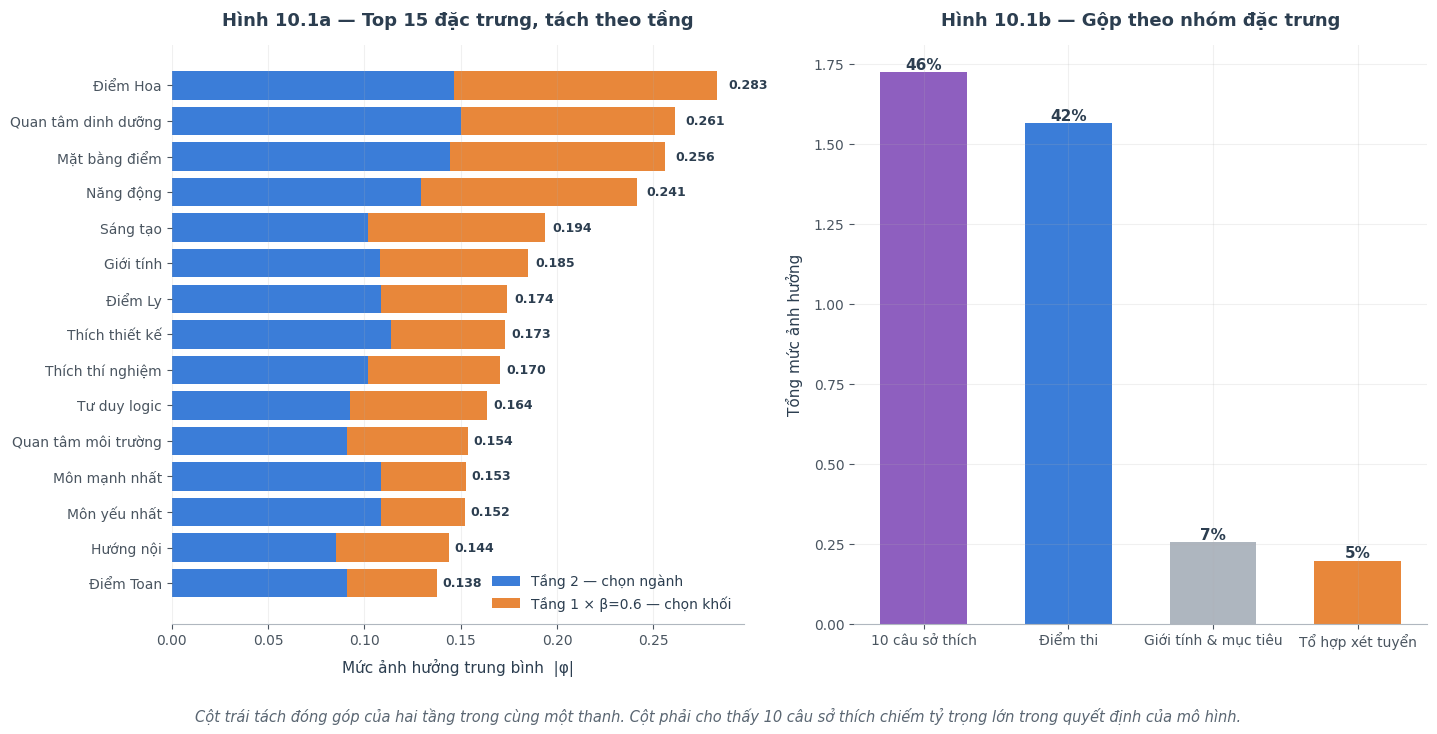

In [7]:
# ═══════════ HÌNH 10.1 — Tầm quan trọng toàn cục ═══════════
top_n = 15
sub = bang.head(top_n).iloc[::-1]
y = np.arange(top_n)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14.5, 7))

ax1.barh(y, sub["shap_tang2"], color=C_XANH, label="Tầng 2 — chọn ngành")
ax1.barh(y, BETA * sub["shap_tang1"], left=sub["shap_tang2"],
         color=C_CAM, label=f"Tầng 1 × β={BETA} — chọn khối")
ax1.set_yticks(y); ax1.set_yticklabels(sub["dac_trung"])
ax1.set_xlabel("Mức ảnh hưởng trung bình  |φ|")
ax1.set_title(f"Hình 10.1a — Top {top_n} đặc trưng, tách theo tầng")
ax1.legend(loc="lower right")
ax1.grid(axis="x", alpha=0.18); ax1.grid(axis="y", visible=False)
for i, v in enumerate(sub["shap_hop_nhat"]):
    ax1.text(v * 1.02, i, f"{v:.3f}", va="center", fontsize=9, fontweight="bold", color=C_DAM)

nhom_mau = {"likert": C_TIM, "diem": C_XANH, "to_hop": C_CAM, "khac": C_XAM}
def nhom(c):
    if c.startswith("likert"): return "likert"
    if c.startswith("diem"):   return "diem"
    if c.startswith(("to_hop", "nhom_to_hop")): return "to_hop"
    return "khac"

tong_nhom = {}
for c, v in zip(COT, hop_nhat):
    tong_nhom[nhom(c)] = tong_nhom.get(nhom(c), 0) + v
ten_hien = {"likert": "10 câu sở thích", "diem": "Điểm thi", "to_hop": "Tổ hợp xét tuyển",
            "khac": "Giới tính & mục tiêu"}
ks = sorted(tong_nhom, key=lambda k: -tong_nhom[k])
ax2.bar(range(len(ks)), [tong_nhom[k] for k in ks],
        color=[nhom_mau[k] for k in ks], width=0.6)
ax2.set_xticks(range(len(ks))); ax2.set_xticklabels([ten_hien[k] for k in ks], fontsize=10)
ax2.set_ylabel("Tổng mức ảnh hưởng")
ax2.set_title("Hình 10.1b — Gộp theo nhóm đặc trưng")
tong_tat = sum(tong_nhom.values())
for i, k in enumerate(ks):
    ax2.text(i, tong_nhom[k], f"{tong_nhom[k]/tong_tat:.0%}",
             ha="center", va="bottom", fontweight="bold", color=C_DAM)
ax2.grid(axis="y", alpha=0.18)

plt.tight_layout()
luu(fig, OUTPUT_DIR, "hinh_10_1_shap_toan_cuc.png",
    "Cột trái tách đóng góp của hai tầng trong cùng một thanh. Cột phải cho thấy "
    "10 câu sở thích chiếm tỷ trọng lớn trong quyết định của mô hình.")
plt.show()

   💾 Đã lưu hình: hinh_10_2_shap_vs_gain.png


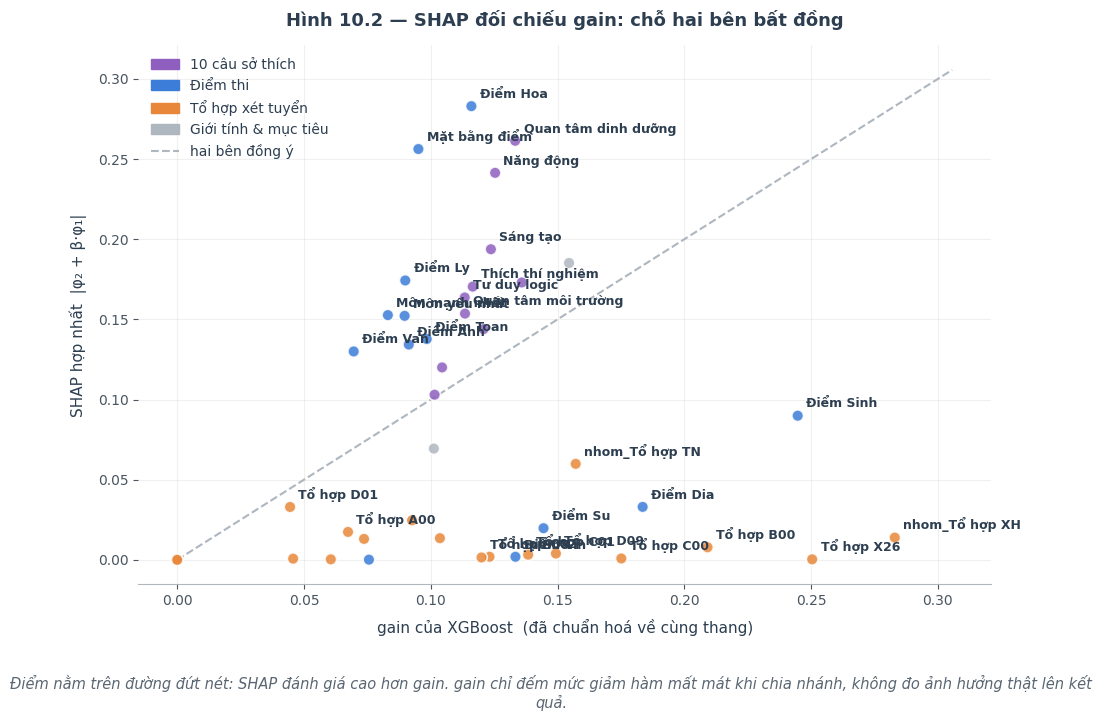

In [8]:
# ═══════════ HÌNH 10.2 — SHAP đối chiếu gain ═══════════
fig, ax = plt.subplots(figsize=(11, 7))

sh = bang["shap_hop_nhat"].values
gn = bang["gain_xgboost"].values
gn_chuan = gn / gn.max() * sh.max() if gn.max() > 0 else gn
mau = [nhom_mau[nhom(c)] for c in bang["dac_trung"].index.map(lambda i: COT[i]) ] \
      if False else [nhom_mau[nhom(COT[TEN_DEP.index(t)])] for t in bang["dac_trung"]]

ax.scatter(gn_chuan, sh, s=70, c=mau, alpha=0.85, edgecolor="white", linewidth=1.2, zorder=3)
lim = max(sh.max(), gn_chuan.max()) * 1.08
ax.plot([0, lim], [0, lim], "--", color=C_XAM, lw=1.5, zorder=1, label="hai bên đồng ý")

# ghi tên những chỗ lệch nhiều nhất
for _, r in bang[bang["lech_hang"].abs() >= 8].iterrows():
    i = TEN_DEP.index(r["dac_trung"])
    ax.annotate(r["dac_trung"],
                (gn_chuan[bang.index[bang["dac_trung"] == r["dac_trung"]][0]],
                 r["shap_hop_nhat"]),
                fontsize=9, fontweight="bold", color=C_DAM,
                xytext=(6, 6), textcoords="offset points")

ax.set_xlabel("gain của XGBoost  (đã chuẩn hoá về cùng thang)")
ax.set_ylabel("SHAP hợp nhất  |φ₂ + β·φ₁|")
ax.set_title("Hình 10.2 — SHAP đối chiếu gain: chỗ hai bên bất đồng")
ax.legend(handles=[Patch(color=v, label=ten_hien[k]) for k, v in nhom_mau.items()]
                  + [plt.Line2D([], [], ls="--", color=C_XAM, label="hai bên đồng ý")],
          loc="upper left")
ax.grid(alpha=0.18)

luu(fig, OUTPUT_DIR, "hinh_10_2_shap_vs_gain.png",
    "Điểm nằm trên đường đứt nét: SHAP đánh giá cao hơn gain. gain chỉ đếm mức giảm "
    "hàm mất mát khi chia nhánh, không đo ảnh hưởng thật lên kết quả.")
plt.show()

## Bước 10.6 — Vì sao 25 trên 39 ngành không bao giờ được đoán trúng

Giai đoạn 8 ghi nhận **25/39 ngành có F1 = 0** trên tập kiểm tra. Chỉ số tổng thể tốt
không che được vấn đề cục bộ này, và SHAP cho phép soi nguyên nhân: những ngành đó có
điểm nền (base value) thấp tới mức nào, và đặc trưng nào có thể kéo chúng lên.

In [9]:
from sklearn.metrics import f1_score

du_doan = diem_that.argmax(1)
f1_tung_nganh = f1_score(y_nganh, du_doan, average=None, labels=np.arange(39), zero_division=0)
nganh_f1_khong = np.where(f1_tung_nganh == 0)[0]
print(f"Số ngành có F1 = 0 : {len(nganh_f1_khong)}/39")

base_tang2 = shap2[:, :, -1].mean(0)          # base value trung bình mỗi ngành
so_lan_top1 = np.bincount(du_doan, minlength=39)
so_mau_that = np.bincount(y_nganh, minlength=39)

bang_nganh = (pd.DataFrame({
        "nganh": [TEN_NGANH[j] for j in range(39)],
        "f1": f1_tung_nganh,
        "base": base_tang2,
        "so_lan_duoc_chon_top1": so_lan_top1,
        "so_mau_trong_test": so_mau_that,
    })
    .sort_values("base"))

print("\n5 NGÀNH CÓ ĐIỂM NỀN THẤP NHẤT (mô hình gần như không bao giờ chọn)\n")
print(bang_nganh.head(5).to_string(index=False, float_format=lambda v: f"{v:.3f}"))
print("\n5 NGÀNH CÓ ĐIỂM NỀN CAO NHẤT\n")
print(bang_nganh.tail(5).to_string(index=False, float_format=lambda v: f"{v:.3f}"))

bang_nganh.to_csv(OUTPUT_DIR / "nen_tang_theo_nganh.csv", index=False)
print(f"\n💾 Đã lưu: nen_tang_theo_nganh.csv")

Số ngành có F1 = 0 : 25/39

5 NGÀNH CÓ ĐIỂM NỀN THẤP NHẤT (mô hình gần như không bao giờ chọn)

                           nganh    f1   base  so_lan_duoc_chon_top1  so_mau_trong_test
   Công nghệ kỹ thuật môi trường 0.000 -0.508                      4                  1
             Quản lý Công nghiệp 0.000 -0.505                      3                  1
     Công nghệ chế biến thủy sản 0.000 -0.449                      4                  1
        Khoa học chế biến món ăn 0.000 -0.418                      2                  1
Kinh doanh thời trang và dệt may 0.000 -0.415                      0                  1

5 NGÀNH CÓ ĐIỂM NỀN CAO NHẤT

              nganh    f1  base  so_lan_duoc_chon_top1  so_mau_trong_test
Tài chính ngân hàng 0.000 0.146                      4                  4
          Marketing 0.000 0.151                      3                  4
            Kế toán 0.333 0.163                      2                  4
Công nghệ thông tin 0.400 0.313                  

   💾 Đã lưu hình: hinh_10_3_nganh_f1_khong.png


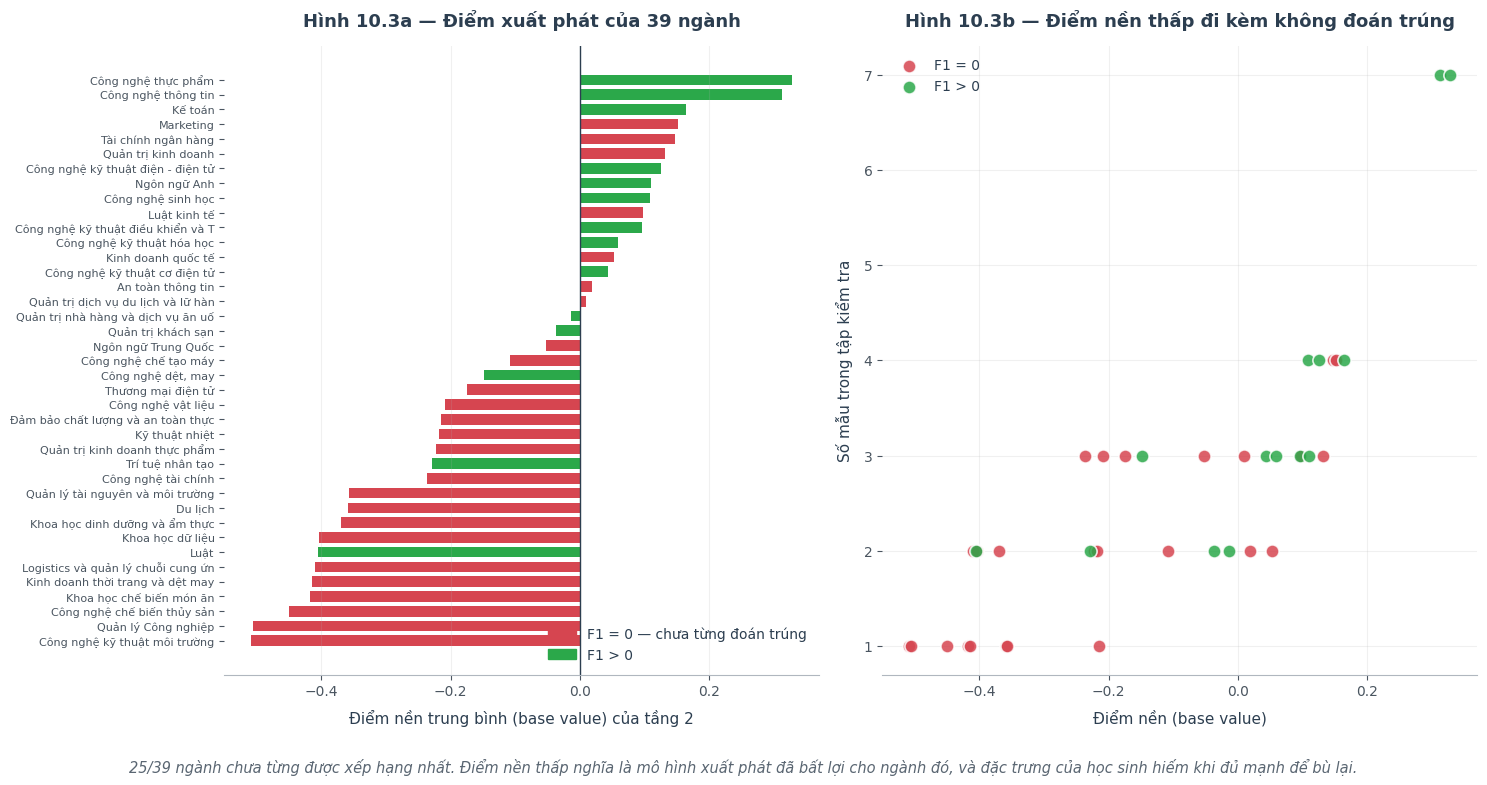

In [10]:
# ═══════════ HÌNH 10.3 — Ngành F1 = 0 ═══════════
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7.5))

bn = bang_nganh.sort_values("base")
mau_bar = [C_THAT if f == 0 else C_GA for f in bn["f1"]]
yy = np.arange(len(bn))
ax1.barh(yy, bn["base"], color=mau_bar, height=0.72)
ax1.set_yticks(yy)
ax1.set_yticklabels([t[:34] for t in bn["nganh"]], fontsize=8)
ax1.axvline(0, color=C_DAM, lw=1)
ax1.set_xlabel("Điểm nền trung bình (base value) của tầng 2")
ax1.set_title("Hình 10.3a — Điểm xuất phát của 39 ngành")
ax1.legend(handles=[Patch(color=C_THAT, label="F1 = 0 — chưa từng đoán trúng"),
                    Patch(color=C_GA,  label="F1 > 0")], loc="lower right")
ax1.grid(axis="x", alpha=0.18); ax1.grid(axis="y", visible=False)

co_f1 = bang_nganh[bang_nganh["f1"] > 0]
khong = bang_nganh[bang_nganh["f1"] == 0]
ax2.scatter(khong["base"], khong["so_mau_trong_test"], s=90, color=C_THAT,
            alpha=0.85, edgecolor="white", linewidth=1.2, label="F1 = 0", zorder=3)
ax2.scatter(co_f1["base"], co_f1["so_mau_trong_test"], s=90, color=C_GA,
            alpha=0.85, edgecolor="white", linewidth=1.2, label="F1 > 0", zorder=3)
ax2.set_xlabel("Điểm nền (base value)")
ax2.set_ylabel("Số mẫu trong tập kiểm tra")
ax2.set_title("Hình 10.3b — Điểm nền thấp đi kèm không đoán trúng")
ax2.legend(); ax2.grid(alpha=0.18)

plt.tight_layout()
luu(fig, OUTPUT_DIR, "hinh_10_3_nganh_f1_khong.png",
    f"{len(nganh_f1_khong)}/39 ngành chưa từng được xếp hạng nhất. Điểm nền thấp nghĩa là "
    "mô hình xuất phát đã bất lợi cho ngành đó, và đặc trưng của học sinh hiếm khi đủ mạnh để bù lại.")
plt.show()

## Bước 10.7 — Thiên lệch giới tính

Bản chạy thử cho thấy `Giới tính` thường đứng đầu bảng đóng góp. Đây là phát hiện phải
nêu trong phần Thảo luận: mô hình học lại **cơ cấu giới tính thực tế của từng ngành**
trong dữ liệu tuyển sinh, nên nó dùng giới tính như một tín hiệu mạnh để đoán ngành.

Cần định lượng thay vì chỉ nhận xét cảm tính.

In [11]:
i_gt = COT.index("gioi_tinh_ma")

# Đóng góp của giới tính cho ngành mà mô hình xếp #1 của từng học sinh
dong_gop_gt = np.array([
    shap2[i, du_doan[i], i_gt] + BETA * shap1[i, KHOI_CUA_NGANH[du_doan[i]], i_gt]
    for i in range(len(X_test))
])
tong_abs_moi_hs = np.array([
    np.abs(shap2[i, du_doan[i], :-1] + BETA * shap1[i, KHOI_CUA_NGANH[du_doan[i]], :-1]).sum()
    for i in range(len(X_test))
])
ty_trong_gt = np.abs(dong_gop_gt) / tong_abs_moi_hs * 100

hang_gt = int(bang.index[bang["dac_trung"] == "Giới tính"][0]) + 1
print(f"Giới tính xếp hạng {hang_gt}/43 về tầm quan trọng toàn cục")
print(f"Tỷ trọng trung bình trong quyết định : {ty_trong_gt.mean():.1f}%")
print(f"Tỷ trọng cao nhất ở một học sinh     : {ty_trong_gt.max():.1f}%")
print(f"Số học sinh mà giới tính là yếu tố MẠNH NHẤT : "
      f"{sum(1 for i in range(len(X_test)) if np.argmax(np.abs(shap2[i, du_doan[i], :-1] + BETA*shap1[i, KHOI_CUA_NGANH[du_doan[i]], :-1])) == i_gt)}"
      f"/{len(X_test)}")

# Ảnh hưởng của giới tính lên từng khối ngành (trung bình |φ| ở tầng 1)
gt_theo_khoi = np.abs(shap1[:, :, i_gt]).mean(0)
print("\nẢnh hưởng của giới tính lên từng khối ngành (tầng 1):")
for k, ten in enumerate(TEN_KHOI):
    print(f"   {ten:36} {gt_theo_khoi[k]:.4f}")

Giới tính xếp hạng 6/43 về tầm quan trọng toàn cục
Tỷ trọng trung bình trong quyết định : 6.8%
Tỷ trọng cao nhất ở một học sinh     : 42.8%
Số học sinh mà giới tính là yếu tố MẠNH NHẤT : 15/102

Ảnh hưởng của giới tính lên từng khối ngành (tầng 1):
   CNTT & Máy tính                      0.1644
   Kinh doanh & Quản lý                 0.1467
   Du lịch, Khách sạn & Ẩm thực         0.0081
   Kỹ thuật & Công nghệ                 0.2538
   Thực phẩm, Sinh học & Môi trường     0.0605
   Luật                                 0.2365
   Ngoại ngữ                            0.0298


   💾 Đã lưu hình: hinh_10_4_thien_lech_gioi_tinh.png


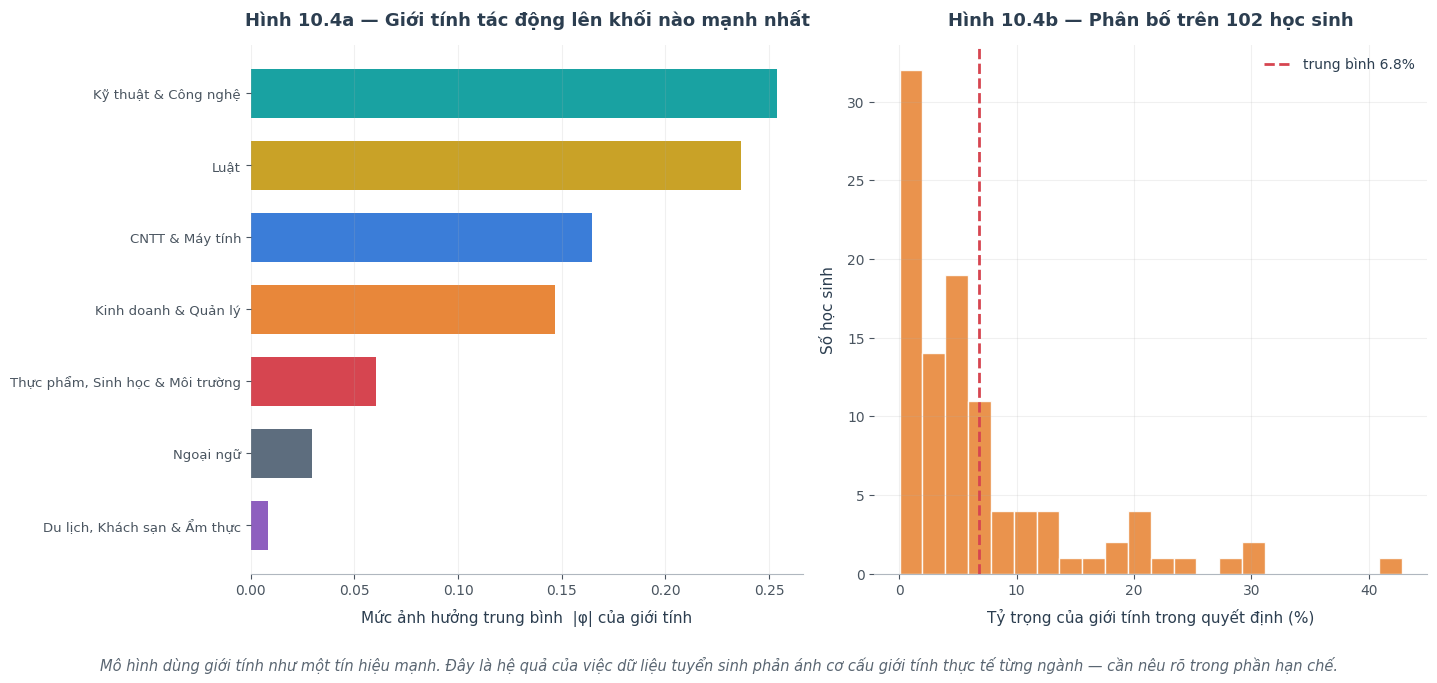

In [12]:
# ═══════════ HÌNH 10.4 — Thiên lệch giới tính ═══════════
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14.5, 6.5))

o = np.argsort(-gt_theo_khoi)
ax1.barh(np.arange(len(TEN_KHOI)), gt_theo_khoi[o],
         color=[C_KHOI[i % len(C_KHOI)] for i in o], height=0.68)
ax1.set_yticks(np.arange(len(TEN_KHOI)))
ax1.set_yticklabels([TEN_KHOI[i][:32] for i in o], fontsize=9.5)
ax1.invert_yaxis()
ax1.set_xlabel("Mức ảnh hưởng trung bình  |φ| của giới tính")
ax1.set_title("Hình 10.4a — Giới tính tác động lên khối nào mạnh nhất")
ax1.grid(axis="x", alpha=0.18); ax1.grid(axis="y", visible=False)

ax2.hist(ty_trong_gt, bins=22, color=C_CAM, edgecolor="white", alpha=0.9)
ax2.axvline(ty_trong_gt.mean(), color=C_THAT, lw=2, ls="--",
            label=f"trung bình {ty_trong_gt.mean():.1f}%")
ax2.set_xlabel("Tỷ trọng của giới tính trong quyết định (%)")
ax2.set_ylabel("Số học sinh")
ax2.set_title("Hình 10.4b — Phân bố trên 102 học sinh")
ax2.legend(); ax2.grid(alpha=0.18)

plt.tight_layout()
luu(fig, OUTPUT_DIR, "hinh_10_4_thien_lech_gioi_tinh.png",
    "Mô hình dùng giới tính như một tín hiệu mạnh. Đây là hệ quả của việc dữ liệu tuyển sinh "
    "phản ánh cơ cấu giới tính thực tế từng ngành — cần nêu rõ trong phần hạn chế.")
plt.show()

## Bước 10.8 — Giải thích một học sinh cụ thể (bản mẫu cho giao diện)

Hình này là bản mẫu trực tiếp cho mục *"Vì sao mô hình xếp ngành này"* trên trang kết
quả. Thầy hướng dẫn yêu cầu *"Waterfall plot hoặc Force plot được đơn giản hoá thành
biểu đồ thanh trực quan cho học sinh dễ hiểu"* — đây chính là dạng đó.

   💾 Đã lưu hình: hinh_10_5_mot_hoc_sinh.png


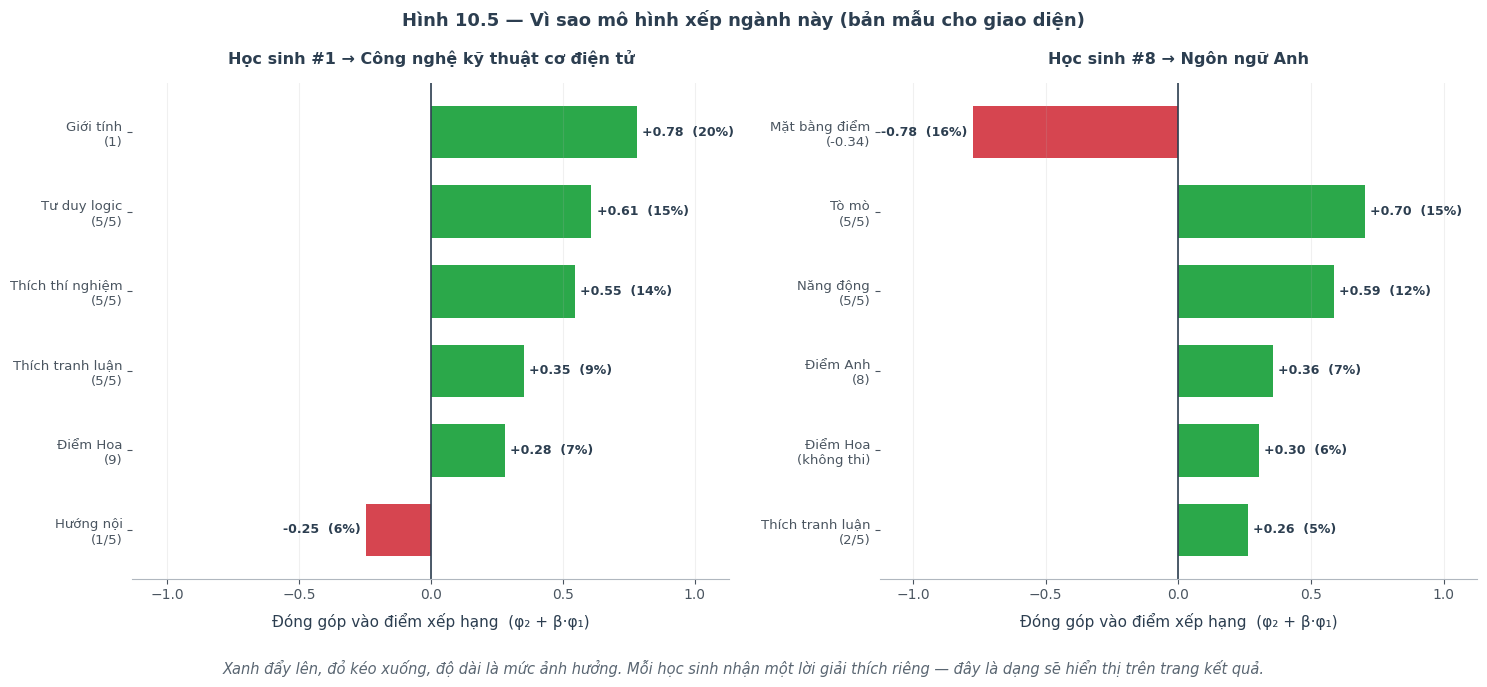

In [13]:
# ═══════════ HÌNH 10.5 — Giải thích một học sinh ═══════════
def ve_mot_hoc_sinh(ax, r, tieu_de):
    fs = r["features"][::-1]
    y = np.arange(len(fs))
    gia_tri = [f["dong_gop"] for f in fs]
    mau = [C_GA if g > 0 else C_THAT for g in gia_tri]
    ax.barh(y, gia_tri, color=mau, height=0.66)
    ax.set_yticks(y)
    ax.set_yticklabels([f'{f["ten"]}\n({f["gia_tri"]})' for f in fs], fontsize=9.5)
    ax.axvline(0, color=C_DAM, lw=1.2)
    for i, (g, f) in enumerate(zip(gia_tri, fs)):
        ax.text(g + (0.02 if g > 0 else -0.02), i, f'{g:+.2f}  ({f["phan_tram"]:.0f}%)',
                va="center", ha="left" if g > 0 else "right",
                fontsize=9, fontweight="bold", color=C_DAM)
    ax.set_xlabel("Đóng góp vào điểm xếp hạng  (φ₂ + β·φ₁)")
    ax.set_title(tieu_de, fontsize=11.5)
    ax.grid(axis="x", alpha=0.18); ax.grid(axis="y", visible=False)
    lim = max(abs(min(gia_tri)), max(gia_tri)) * 1.45
    ax.set_xlim(-lim, lim)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6.5))
r0 = giai_thich(0); r7 = giai_thich(7)
ve_mot_hoc_sinh(ax1, r0, f'Học sinh #1 → {r0["nganh"]}')
ve_mot_hoc_sinh(ax2, r7, f'Học sinh #8 → {r7["nganh"]}')
fig.suptitle("Hình 10.5 — Vì sao mô hình xếp ngành này (bản mẫu cho giao diện)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
luu(fig, OUTPUT_DIR, "hinh_10_5_mot_hoc_sinh.png",
    "Xanh đẩy lên, đỏ kéo xuống, độ dài là mức ảnh hưởng. Mỗi học sinh nhận một lời giải "
    "thích riêng — đây là dạng sẽ hiển thị trên trang kết quả.")
plt.show()

## Bước 10.9 — Hai chế độ giải thích khác nhau ra sao

Chế độ **Khám phá** dùng cả hai tầng. Chế độ **Tư vấn** có `P₁ = 1` nên tầng 1 biến mất
khỏi công thức. Hình này minh hoạ trực tiếp §2 của kế hoạch: đóng góp hợp nhất tách được
thành hai phần cộng lại.

   💾 Đã lưu hình: hinh_10_6_hai_che_do.png


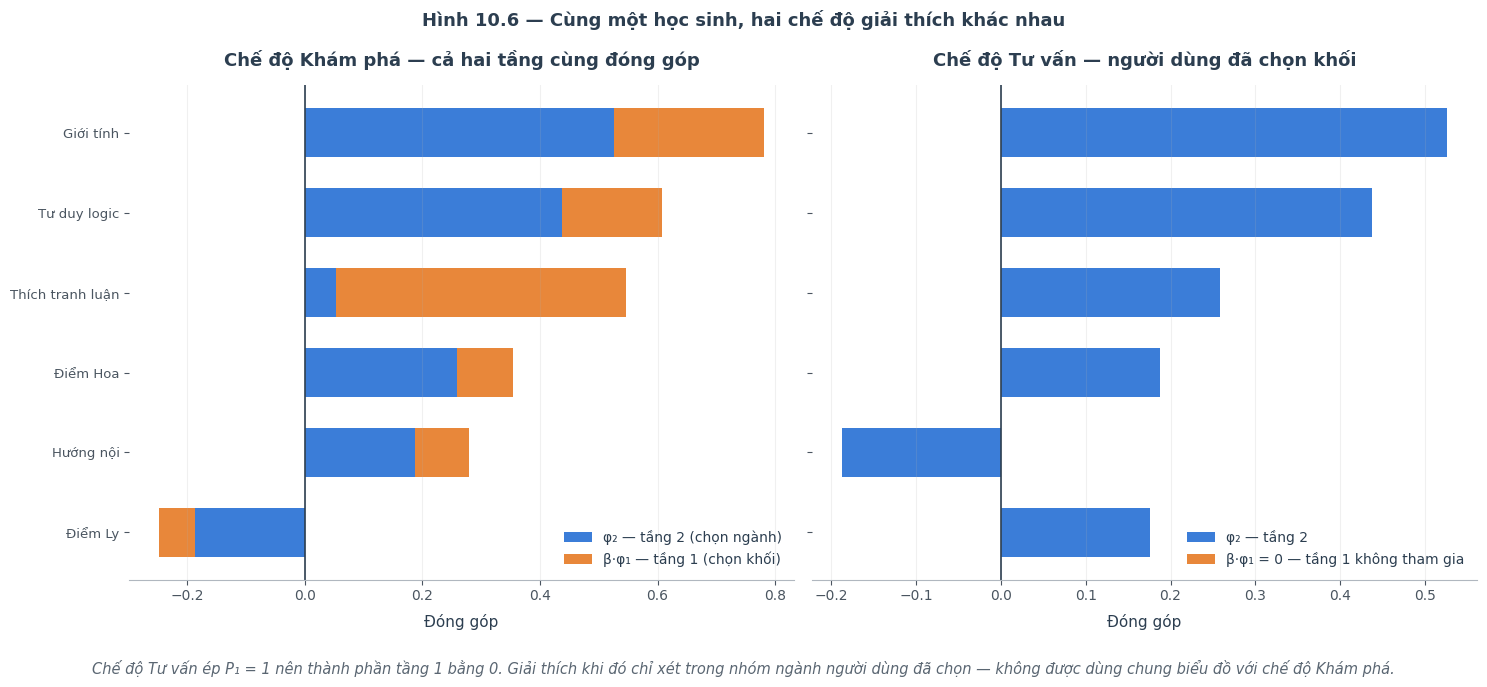

In [14]:
# ═══════════ HÌNH 10.6 — Tách hai tầng, hai chế độ ═══════════
r_kp = giai_thich(0, mode="explore")
r_tv = giai_thich(0, mode="guided", j_nganh=int(diem_that[0].argmax()))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6.5), sharey=True)

fs = r_kp["features"][::-1]
y = np.arange(len(fs))
t2 = np.array([f["tang2"] for f in fs])
t1 = np.array([f["tang1"] for f in fs])
ax1.barh(y, t2, color=C_XANH, height=0.62, label="φ₂ — tầng 2 (chọn ngành)")
ax1.barh(y, t1, left=t2, color=C_CAM, height=0.62, label=f"β·φ₁ — tầng 1 (chọn khối)")
ax1.set_yticks(y); ax1.set_yticklabels([f["ten"] for f in fs], fontsize=9.5)
ax1.axvline(0, color=C_DAM, lw=1.2)
ax1.set_title("Chế độ Khám phá — cả hai tầng cùng đóng góp")
ax1.set_xlabel("Đóng góp"); ax1.legend(loc="lower right")
ax1.grid(axis="x", alpha=0.18); ax1.grid(axis="y", visible=False)

fs2 = r_tv["features"][::-1]
ax2.barh(np.arange(len(fs2)), [f["tang2"] for f in fs2], color=C_XANH, height=0.62,
         label="φ₂ — tầng 2")
ax2.barh(np.arange(len(fs2)), [f["tang1"] for f in fs2], color=C_CAM, height=0.62,
         label="β·φ₁ = 0 — tầng 1 không tham gia")
ax2.set_yticks(np.arange(len(fs2)))
ax2.set_yticklabels([f["ten"] for f in fs2], fontsize=9.5)
ax2.axvline(0, color=C_DAM, lw=1.2)
ax2.set_title("Chế độ Tư vấn — người dùng đã chọn khối")
ax2.set_xlabel("Đóng góp"); ax2.legend(loc="lower right")
ax2.grid(axis="x", alpha=0.18); ax2.grid(axis="y", visible=False)

fig.suptitle("Hình 10.6 — Cùng một học sinh, hai chế độ giải thích khác nhau",
             fontsize=13, fontweight="bold")
plt.tight_layout()
luu(fig, OUTPUT_DIR, "hinh_10_6_hai_che_do.png",
    "Chế độ Tư vấn ép P₁ = 1 nên thành phần tầng 1 bằng 0. Giải thích khi đó chỉ xét "
    "trong nhóm ngành người dùng đã chọn — không được dùng chung biểu đồ với chế độ Khám phá.")
plt.show()

## Bước 10.10 — Xuất kết quả cho backend

Xuất bảng dịch tên và tầm quan trọng toàn cục để backend và giao diện dùng lại, khỏi
tính lại hay gõ tay.

In [15]:
ket_qua = {
    "ngay_chay": pd.Timestamp.now().strftime("%Y-%m-%d %H:%M"),
    "seed": SEED,
    "beta": BETA,
    "n_mau_test": int(len(X_test)),
    "thuat_toan": "TreeSHAP qua xgboost pred_contribs (không dùng thư viện shap để tính)",
    "kiem_chung": {
        "cong_tinh_tang1": float(sai1),
        "cong_tinh_tang2": float(sai2),
        "trung_top1": float(trung_top1),
        "trung_toan_bo_thu_hang": float(trung_bang),
    },
    "ten_dac_trung": {c: ten_dep(c) for c in COT},
    "tam_quan_trong_toan_cuc": {
        t: float(v) for t, v in zip(TEN_DEP, hop_nhat)
    },
    "thien_lech_gioi_tinh": {
        "hang_toan_cuc": hang_gt,
        "ty_trong_trung_binh_pct": float(ty_trong_gt.mean()),
        "ty_trong_cao_nhat_pct": float(ty_trong_gt.max()),
    },
    "nganh_f1_khong": [TEN_NGANH[int(j)] for j in nganh_f1_khong],
}
(OUTPUT_DIR / "ket_qua_xai.json").write_text(
    json.dumps(ket_qua, ensure_ascii=False, indent=2), encoding="utf-8")

print("💾 Đã lưu: ket_qua_xai.json\n")
print(json.dumps({k: v for k, v in ket_qua.items()
                  if k not in ("ten_dac_trung", "tam_quan_trong_toan_cuc")},
                 ensure_ascii=False, indent=2))

💾 Đã lưu: ket_qua_xai.json

{
  "ngay_chay": "2026-09-04 01:13",
  "seed": 42,
  "beta": 0.6,
  "n_mau_test": 102,
  "thuat_toan": "TreeSHAP qua xgboost pred_contribs (không dùng thư viện shap để tính)",
  "kiem_chung": {
    "cong_tinh_tang1": 1.1920928955078125e-06,
    "cong_tinh_tang2": 2.1457672119140625e-06,
    "trung_top1": 1.0,
    "trung_toan_bo_thu_hang": 1.0
  },
  "thien_lech_gioi_tinh": {
    "hang_toan_cuc": 6,
    "ty_trong_trung_binh_pct": 6.773978187721016,
    "ty_trong_cao_nhat_pct": 42.81368775827129
  },
  "nganh_f1_khong": [
    "Ngôn ngữ Trung Quốc",
    "Quản trị kinh doanh",
    "Marketing",
    "Kinh doanh quốc tế",
    "Thương mại điện tử",
    "Kinh doanh thời trang và dệt may",
    "Quản trị kinh doanh thực phẩm",
    "Tài chính ngân hàng",
    "Công nghệ tài chính",
    "Luật kinh tế",
    "Khoa học dữ liệu",
    "An toàn thông tin",
    "Công nghệ chế tạo máy",
    "Công nghệ vật liệu",
    "Công nghệ kỹ thuật môi trường",
    "Quản lý Công nghiệp",
    

## Tổng kết Giai đoạn 10

### Đã kiểm chứng
- **Tính cộng tính**: `Σφ + base = margin` ở cả hai tầng, sai lệch < 1e-4
- **Công thức hợp nhất**: `φ₂ + β·φ₁` tái tạo **đúng 100%** thứ hạng 39 ngành trên cả
  102 học sinh — nên hệ thống hiển thị **một** biểu đồ giải thích thay vì hai
- **Chế độ Tư vấn**: thành phần tầng 1 bằng 0, đúng thiết kế

### Phải nêu trong phần Thảo luận của báo cáo
1. **Mô hình dựa nhiều vào giới tính.** Hệ quả của việc dữ liệu tuyển sinh phản ánh cơ
   cấu giới tính thực tế từng ngành. XAI soi ra được điều này — đó chính là giá trị của nó.
2. **25/39 ngành có F1 = 0** đi kèm điểm nền thấp: mô hình xuất phát đã bất lợi cho các
   ngành đó.
3. **Ranh giới diễn giải.** SHAP nói *mô hình đã dựa vào đâu*, **không** chứng minh
   *điều đó đúng với người dùng*. Với Top-1 = 17,6%, câu chữ trên giao diện phải là
   *"mô hình xếp ngành này cao vì…"*, tuyệt đối không phải *"bạn hợp ngành này vì…"*.

### Bước tiếp theo
Backend: bê `giai_thich()` sang `major_predictor.py`, thêm khoá `explain` vào kết quả,
lưu vào `prediction_history`, mở `GET /api/v1/explain/{prediction_id}`.